# 01 · Simple linear regression: estimating a stock’s beta

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/01_simple_linear_regression.ipynb)

**Goal:** estimate the CAPM beta of a stock by regressing its monthly excess return on the market’s excess
return, first **by hand with the CFA formulas**, then with `statsmodels` to check every number.

Dataset: `factor_returns.csv` (120 simulated months).

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = "../data/" if Path("../data").exists() else "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/"
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
df = pd.read_csv(DATA + "factor_returns.csv")
X = df["mkt_excess"].to_numpy()
Y = df["stock_excess"].to_numpy()
n = len(Y)
print("n =", n)

n = 120


## Step 1. Slope and intercept from the formulas
$\hat b_1 = \dfrac{\sum (X_i-\bar X)(Y_i-\bar Y)}{\sum (X_i-\bar X)^2}, \qquad \hat b_0 = \bar Y - \hat b_1 \bar X$

In [3]:
x_bar, y_bar = X.mean(), Y.mean()
b1 = ((X - x_bar) * (Y - y_bar)).sum() / ((X - x_bar) ** 2).sum()
b0 = y_bar - b1 * x_bar
print(f"beta (b1) = {b1:.4f},  alpha (b0) = {b0:.4f}")

beta (b1) = 1.3040,  alpha (b0) = -0.4607


## Step 2. Variance decomposition: SST = SSR + SSE

In [4]:
Y_hat = b0 + b1 * X
resid = Y - Y_hat
SST = ((Y - y_bar) ** 2).sum()
SSR = ((Y_hat - y_bar) ** 2).sum()
SSE = (resid ** 2).sum()
R2 = SSR / SST
SEE = np.sqrt(SSE / (n - 2))
print(f"SST={SST:.1f}  SSR={SSR:.1f}  SSE={SSE:.1f}  (SSR+SSE={SSR+SSE:.1f})")
print(f"R^2 = {R2:.4f}   SEE = {SEE:.4f}   check: corr^2 = {np.corrcoef(X, Y)[0,1]**2:.4f}")

SST=5316.9  SSR=2305.0  SSE=3011.9  (SSR+SSE=5316.9)
R^2 = 0.4335   SEE = 5.0522   check: corr^2 = 0.4335


## Step 3. Is the slope significant? t-test with n − 2 degrees of freedom

In [5]:
from scipy import stats
s_b1 = SEE / np.sqrt(((X - x_bar) ** 2).sum())
t_stat = (b1 - 0) / s_b1
t_crit = stats.t.ppf(0.975, df=n - 2)
p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=n - 2))
print(f"s_b1 = {s_b1:.4f}, t = {t_stat:.2f}, critical t = {t_crit:.3f}, p = {p_val:.2e}")
print("Reject H0: b1 = 0" if abs(t_stat) > t_crit else "Fail to reject H0")

s_b1 = 0.1372, t = 9.50, critical t = 1.980, p = 2.22e-16
Reject H0: b1 = 0


## Step 4. ANOVA table and the F-statistic (F = t² in simple regression)

In [6]:
MSR, MSE = SSR / 1, SSE / (n - 2)
anova = pd.DataFrame({"df": [1, n - 2, n - 1], "SS": [SSR, SSE, SST], "MS": [MSR, MSE, np.nan]},
                     index=["Regression", "Error", "Total"])
print(anova.round(3)); print("F =", round(MSR / MSE, 3), "| t^2 =", round(t_stat ** 2, 3))

             df        SS        MS
Regression    1  2305.011  2305.011
Error       118  3011.877    25.524
Total       119  5316.888       NaN
F = 90.306 | t^2 = 90.306


## Step 5. Same thing in two lines with statsmodels
Always add a constant: `sm.add_constant` creates the intercept column.

In [7]:
model = sm.OLS(df["stock_excess"], sm.add_constant(df["mkt_excess"])).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           stock_excess   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     90.31
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           3.02e-16
Time:                        16:01:28   Log-Likelihood:                -363.64
No. Observations:                 120   AIC:                             731.3
Df Residuals:                     118   BIC:                             736.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4607      0.465     -0.990      0.3

## Step 6. Plot the fit and the residuals

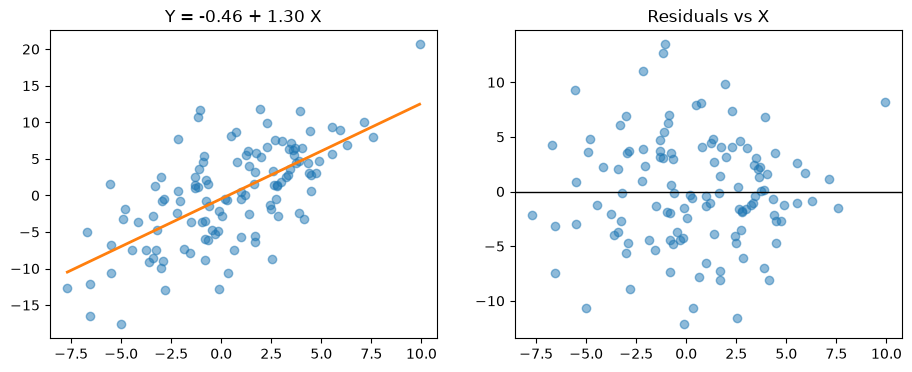

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X, Y, alpha=0.5); xs = np.linspace(X.min(), X.max(), 50)
ax[0].plot(xs, b0 + b1 * xs, color="C1", lw=2); ax[0].set_title(f"Y = {b0:.2f} + {b1:.2f} X")
ax[1].scatter(X, resid, alpha=0.5); ax[1].axhline(0, color="k", lw=1); ax[1].set_title("Residuals vs X")
plt.show()

## Step 7. Prediction interval for a −5% market month

In [9]:
new = pd.DataFrame({"const": [1.0], "mkt_excess": [-5.0]})
pred = model.get_prediction(new).summary_frame(alpha=0.05)
pred[["mean", "obs_ci_lower", "obs_ci_upper"]]   # obs_ci = prediction interval for a single new Y

,mean,obs_ci_lower,obs_ci_upper
0,-6.9809,-17.1353,3.1736


### Exercise 1

Regress `fund_excess` on `mkt_excess`. Store the beta, its t-statistic and R² in `beta_fund`, `t_fund` and `r2_fund`.

<details><summary>Hint</summary>

Copy Step 5 and change the column name.

</details>

In [10]:
# Your code here

In [11]:
check("01.1")   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 01.1: not answered yet. Store your answer in `beta_fund`, `t_fund`, `r2_fund`.


False

### Exercise 2

For the **stock**, test H₀: β = 1 against H₁: β ≠ 1 at the 5% level. Compute t by hand using `b1` and `s_b1` from above. Store it in `t_beta1`, and store `True`/`False` in `reject_beta1`.

<details><summary>Hint</summary>

t = (b1 − 1) / s_b1, then compare with `t_crit`. Or use `model.t_test('mkt_excess = 1')`.

</details>

In [12]:
# Your code here

In [13]:
check("01.2")   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 01.2: not answered yet. Store your answer in `t_beta1`, `reject_beta1`.


False

### Exercise 3

What is the 95% prediction interval for the stock’s excess return when the market returns **+8%**? Store the bounds in `pi_lower` and `pi_upper`. Why is it wider than the interval at the mean of X?

In [14]:
# Your code here

In [15]:
check("01.3")   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 01.3: not answered yet. Store your answer in `pi_lower`, `pi_upper`.


False

### Exercise 4

Run a log-log style check: does the scatter look linear? What would a log transformation do here (hint: returns can be negative)?

In [16]:
# Your code here

---
## Solutions

In [17]:
# 1
fm = sm.OLS(df["fund_excess"], sm.add_constant(df["mkt_excess"])).fit()
beta_fund, t_fund, r2_fund = fm.params["mkt_excess"], fm.tvalues["mkt_excess"], fm.rsquared
print("beta", round(beta_fund, 4), "t", round(t_fund, 2), "R2", round(r2_fund, 4))
# 2
t_beta1 = (b1 - 1) / s_b1
reject_beta1 = abs(t_beta1) > t_crit
print("t for H0 beta=1:", round(t_beta1, 3), "->", "reject" if reject_beta1 else "fail to reject")
# 3
pi = model.get_prediction(pd.DataFrame({"const": [1.0], "mkt_excess": [8.0]})).summary_frame()
pi_lower, pi_upper = pi["obs_ci_lower"].iloc[0], pi["obs_ci_upper"].iloc[0]
print("95% prediction interval:", round(pi_lower, 2), "to", round(pi_upper, 2))
print("Wider because (Xf - X̄)^2 in s_f grows as Xf moves away from the mean of X =", round(x_bar, 2))
# 4
print("Returns include negatives, so ln(Y) is undefined; the scatter is linear, so the plain linear model is appropriate.")
check_all("01")

beta 0.9478 t 15.7 R2 0.6762
t for H0 beta=1: 2.216 -> reject
95% prediction interval: -0.28 to 20.23
Wider because (Xf - X̄)^2 in s_f grows as Xf moves away from the mean of X = 0.44
Returns include negatives, so ln(Y) is undefined; the scatter is linear, so the plain linear model is appropriate.
✅ Exercise 01.1: correct.
✅ Exercise 01.2: correct.
✅ Exercise 01.3: correct.

3 of 3 exercises correct.


True